In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch

from transformers import GPT2Tokenizer, GPT2LMHeadModel, logging

logging.set_verbosity_error()

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
# Import model and tokenizer from HF
model_name = "gpt2-medium"
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained(model_name).to(device)

model.eval();

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

# Implant hooks for hidden states

In [4]:
scaling_factor_dict = {}

def implant_hook(layer_number):
  def hook(module, input, output):

    if layer_number in scaling_factor_dict.keys():
      hs, *rest = output
      scaling_factor = scaling_factor_dict[layer_number]
      hs.mul_(scaling_factor)
      output = tuple([hs] + rest)

    return output
  return hook

num_layers = model.config.n_layer

for layeri in range(num_layers):
  model.transformer.h[layeri].register_forward_hook(implant_hook(layeri))



# Import text, encode and forward-pass through the model

In [8]:
# quote from Einstein (missing final word is "curious")
text = 'I have no special talent. I am only passionately'
tokens = tokenizer(text, return_tensors='pt').to(device)

target_word = ' curious'
target_token = tokenizer(target_word).input_ids[0]

print(f'Traget token id is {target_token}')

out = model(**tokens)

pure_logits = out.logits.detach()


Traget token id is 11040


# Scale the hidden transformer layer 2 and visualize the difference

In [10]:
scaling_factor_dict = {2: .6}
out = model(**tokens)
scaled_logits = out.logits.detach()

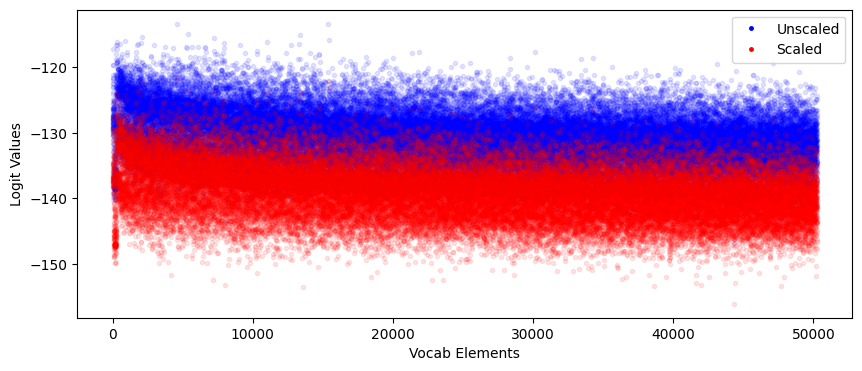

In [16]:
# Visualize
plt.figure(figsize=(10,4))
plt.plot(pure_logits[0,-1,:].cpu(),'b.', alpha=.1, label='Unscaled')
plt.plot(scaled_logits[0,-1,:].cpu(),'r.', alpha=.1, label='Scaled')
plt.gca().set(xlabel='Vocab Elements', ylabel='Logit Values')
h = plt.legend()
for hi in h.legend_handles:
  hi.set(ms=5, alpha=1)

plt.show()

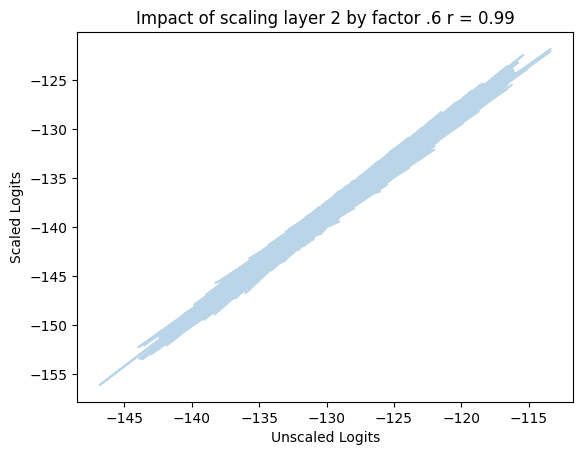

In [25]:
#Scatter plot for scaled vs unscaled logits
r = np.corrcoef(pure_logits[0,-1,:].cpu(), scaled_logits[0,-1,:].cpu())[0,1]

plt.plot(pure_logits[0,-1,:].cpu(), scaled_logits[0,-1,:].cpu(), alpha=.3, ms=3)
plt.gca().set(xlabel='Unscaled Logits', ylabel='Scaled Logits', title=f'Impact of scaling layer 2 by factor .6 r = {r:.2f}')

plt.show()

# Select the top-10 logits from each of the scaled and unscaled outputs

In [67]:
top10_scaled = torch.argsort(scaled_logits[0,-1,:], descending=True).detach().tolist()
top10_pure = torch.argsort(pure_logits[0,-1,:], descending=True).detach().tolist()

print(' '*len(text),'Unscaled   |    Scaled')
print(' '*len(text),'-'*30)
for i in range(10):
  print(f'{text} {tokenizer.decode(top10_pure[i]):12} | {tokenizer.decode(top10_scaled[i]):12}')

                                                 Unscaled   |    Scaled
                                                 ------------------------------
I have no special talent. I am only passionately  interested  |  interested 
I have no special talent. I am only passionately  passionate  |  passionate 
I have no special talent. I am only passionately  committed   |  trying     
I have no special talent. I am only passionately  devoted     |  pursuing   
I have no special talent. I am only passionately  trying      |  doing      
I have no special talent. I am only passionately  dedicated   |  working    
I have no special talent. I am only passionately  pursuing    |  committed  
I have no special talent. I am only passionately  good        |  curious    
I have no special talent. I am only passionately  and         |  devoted    
I have no special talent. I am only passionately  curious     |  dedicated  


# Calculate the loss with respect to the target token

In [49]:
pure_logits[0,-1,:].shape

torch.Size([50257])

In [68]:
pure_loss = -torch.nn.functional.log_softmax(pure_logits[0,-1,:], dim=-1)[target_token]
scaled_loss = -torch.nn.functional.log_softmax(scaled_logits[0,-1,:], dim=-1)[target_token]

scales = list(scaling_factor_dict.items())[0]
print(f'When scaling layer {scales[0]} by {scales[1]}:')
print(f'Unscaled loss: {pure_loss:.4f}')
print(f'Scaled loss: {scaled_loss:.4f}')

When scaling layer 2 by 0.6:
Unscaled loss: 4.3544
Scaled loss: 3.8904


# Losses over all layers for scaled and unscaled models

In [95]:
# Initialize
scaled_losses = np.zeros(num_layers)
logit_corr = np.zeros(num_layers)

# Losses for Unscaled model
pure_losses = -torch.nn.functional.log_softmax(pure_logits[0,-1,:], dim=-1).cpu().numpy()

# Calculate
for layeri in range(num_layers):
  scaling_factor_dict = {layeri: .6}
  with torch.no_grad(): out = model(**tokens)

  scaled_logits = out.logits.detach()

  scaled_loss = -torch.nn.functional.log_softmax(scaled_logits[0,-1,:], dim=-1).cpu().numpy()

  logit_corr[layeri] = np.corrcoef(pure_losses, scaled_loss)[0,1]

  scaled_losses[layeri] = scaled_loss[target_token]

In [84]:
pure_logits[0,-1,:]

tensor([-122.9937, -121.2327, -129.2999,  ..., -130.4992, -127.7061,
        -124.4460], device='cuda:0')

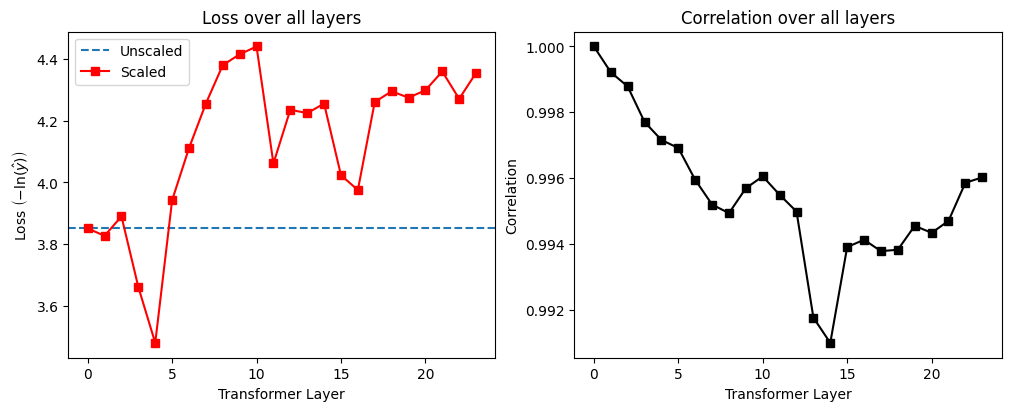

In [105]:
# Visualize
plt.figure(figsize=(10,4), layout='constrained')
plt.subplot(1,2,1)
plt.axhline(y=pure_losses[target_token], linestyle='--', label='Unscaled')
plt.plot(scaled_losses, 'rs-', label='Scaled')
plt.gca().set(xlabel='Transformer Layer', ylabel='Loss $\\left(-\\ln(\\hat{y})\\right)$', title='Loss over all layers')
plt.legend()


plt.subplot(1,2,2)
plt.plot(logit_corr, 'ks-')
plt.gca().set(xlabel='Transformer Layer', ylabel='Correlation', title='Correlation over all layers')

plt.show()